# Final Project
Sagar Biswas <br>
MSDS 422-DL <br>
June 7, 2026

## Executive Summary

<p>Employment outcomes are used as a key performance indicator for higher education institutions. The employability and satisfaction of graduates has a major impact on a university's reputation, rankings, admissions recruitment, and relationships with employers. The ability to predict employment outcomes, such as post-graduate salary, would be valuable to universities.</p>
<p>This project aims to predict post-graduate salary and proactively identify students who may be at risk of less desirable outcomes. This uses historical data from engineering graduates from Indian universities, including academic records, university characteristics, and test scores. The objective is to evaluate whether salary outcomes can be predicted using information available prior to placement while also identifying attributes that most influence salary differences.</p>

## Research Objectives

<p>Universities are always facing pressure to improve post-graduation outcomes for students. These outcomes are usually evaluated retrospectively, after students have already graduated. A predictive framework would help to understand which factors influence post-graduate outcomes the most and how they can be used to identify students while they are still enrolled to prepare them better for the best outcomes.</p>
<p>The primary research objectives are to determine whether post-graduate salary can be reliably predicted and which student indicators have the strongest influence on salary variation.</p>
<p>Although the dataset reflects the population of Indian university engineering students and graduates, the objective of understanding salary indicators and the analytical techniques used remain transferable to broader university contexts.

## Dataset Source

The dataset used in this analysis uses the Kaggle dataset <strong>Engineering Graduate Salary Prediction</strong>, published by Kaggle contributor Manish KC. The underlying data originates from 'Aspiring Minds Research', which captures salary information for engineering graduates in India.

Kaggle dataset link: https://www.kaggle.com/datasets/manishkc06/engineering-graduate-salary-prediction/

## Exploratory Data Analysis

In [1]:
# multiple outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor as RF, GradientBoostingRegressor as GBR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# show full data width
pd.set_option('display.max_columns', None)
# suppress scientific notation
pd.set_option('display.float_format', '{:,.2f}'.format)

In [4]:
# load dataset
df = pd.read_csv('Engineering_graduate_salary.csv')
print(f'Full dataset shape: {df.shape}')

Full dataset shape: (2998, 34)


In [5]:
# inspect data
df.head()
df.info()

,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,Degree,Specialization,collegeGPA,CollegeCityID,CollegeCityTier,CollegeState,GraduationYear,English,Logical,Quant,Domain,ComputerProgramming,ElectronicsAndSemicon,ComputerScience,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,B.Tech/B.E.,instrumentation and control engineering,73.82,6920,1,Delhi,2013,650,665,810,0.69,485,366,-1,-1,-1,-1,-1,-0.16,0.38,1.24,0.15,0.29,445000
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,B.Tech/B.E.,computer science & engineering,65.00,6624,0,Uttar Pradesh,2014,440,435,210,0.34,365,-1,-1,-1,-1,-1,-1,1.13,0.05,1.24,0.53,-0.29,110000
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,B.Tech/B.E.,electronics & telecommunications,61.94,9084,0,Maharashtra,2011,485,475,505,0.82,-1,400,-1,-1,-1,260,-1,0.51,-0.12,1.54,-0.29,-0.29,255000
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,B.Tech/B.E.,computer science & engineering,80.40,8195,1,Delhi,2013,675,620,635,0.99,655,-1,-1,-1,-1,-1,-1,-0.45,0.21,0.32,0.27,0.48,420000
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,B.Tech/B.E.,biotechnology,64.30,4889,1,Tamil Nadu,2012,575,495,365,0.28,315,-1,-1,-1,-1,-1,-1,-1.50,-0.75,-1.07,0.06,0.19,200000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2998 entries, 0 to 2997
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2998 non-null   int64  
 1   Gender                 2998 non-null   object 
 2   DOB                    2998 non-null   object 
 3   10percentage           2998 non-null   float64
 4   10board                2998 non-null   object 
 5   12graduation           2998 non-null   int64  
 6   12percentage           2998 non-null   float64
 7   12board                2998 non-null   object 
 8   CollegeID              2998 non-null   int64  
 9   CollegeTier            2998 non-null   int64  
 10  Degree                 2998 non-null   object 
 11  Specialization         2998 non-null   object 
 12  collegeGPA             2998 non-null   float64
 13  CollegeCityID          2998 non-null   int64  
 14  CollegeCityTier        2998 non-null   int64  
 15  Coll

In [6]:
# drop IDs
df = df.drop('ID', axis = 1)
# separate response and predictors
response = 'Salary'
response_col = [col for col in df.columns if col == response]
predictors = [col for col in df.columns if col != response]
print(f'Shape: {df.shape[0]} observations, {df.shape[1]} columns')
print(f'Response variable: {response}')
print(f'Predictors: {len(predictors)} columns')

Shape: 2998 observations, 33 columns
Response variable: Salary
Predictors: 32 columns


In [7]:
# check duplicates and missing values
duplicate_count = df.duplicated().sum()
missing_values = df.isna().sum().sum()
print(f'Missing values count: {missing_values}')
print(f'Duplicate row count: {duplicate_count}')

Missing values count: 0
Duplicate row count: 0


There are no duplicate observations or literal null values.

### Response variable descriptive statistics

In [8]:
# summary stats
df[response].describe().round(2)

count       2,998.00
mean      305,174.78
std       212,331.19
min        35,000.00
25%       180,000.00
50%       300,000.00
75%       370,000.00
max     4,000,000.00
Name: Salary, dtype: float64

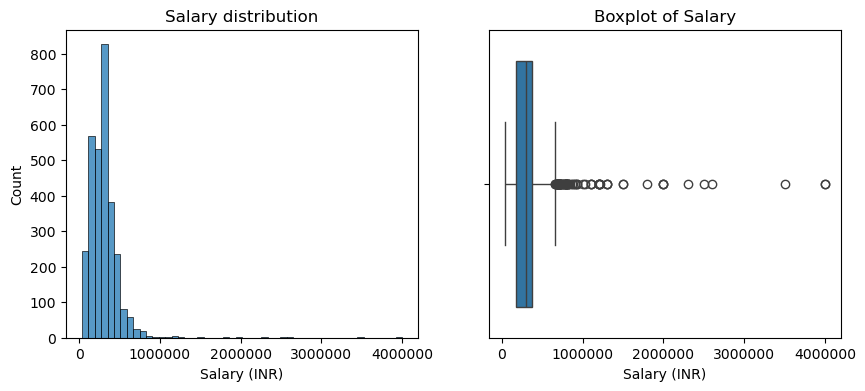

In [9]:
# distribution plot
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
sns.histplot(df[response], bins = 50, ax = axes[0])
axes[0].set_title('Salary distribution')
axes[0].ticklabel_format(axis = 'x', style = 'plain')
axes[0].set_xlabel('Salary (INR)')
sns.boxplot(df[response], orient = 'h', ax = axes[1])
axes[1].set_title('Boxplot of Salary')
axes[1].ticklabel_format(axis = 'x', style = 'plain')
axes[1].set_xlabel('Salary (INR)')
plt.show();

In [10]:
# check skew and kurtosis
salary_mean = df[response].mean()
salary_med = df[response].median()
salary_skew = df[response].skew()
salary_kurt = df[response].kurt()
print(f'Mean salary = ₹{salary_mean:,.2f}, Median salary = ₹{salary_med:,.2f}')
print(f'Skew = {salary_skew:.2f}, Kurtosis = {salary_kurt:.2f}')

Mean salary = ₹305,174.78, Median salary = ₹300,000.00
Skew = 6.96, Kurtosis = 94.13


In [11]:
# calculate outliers
salary_q1 = df[response].quantile(0.25)
salary_q3 = df[response].quantile(0.75)
salary_iqr = salary_q3 - salary_q1
lower_bound = salary_q1 - 1.5 * salary_iqr
upper_bound = salary_q3 + 1.5 * salary_iqr
print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')
salary_outliers = df[(df[response] < lower_bound) | (df[response] > upper_bound)]
print(f'Number of outliers in salary: {len(salary_outliers)}')
print(f'Percentage of dataset: {len(salary_outliers) / len(df) * 100:.2f}%')

Lower bound: -105000.00
Upper bound: 655000.00
Number of outliers in salary: 78
Percentage of dataset: 2.60%


In [12]:
# log transformation
df['l_Salary'] = np.log(df['Salary'])

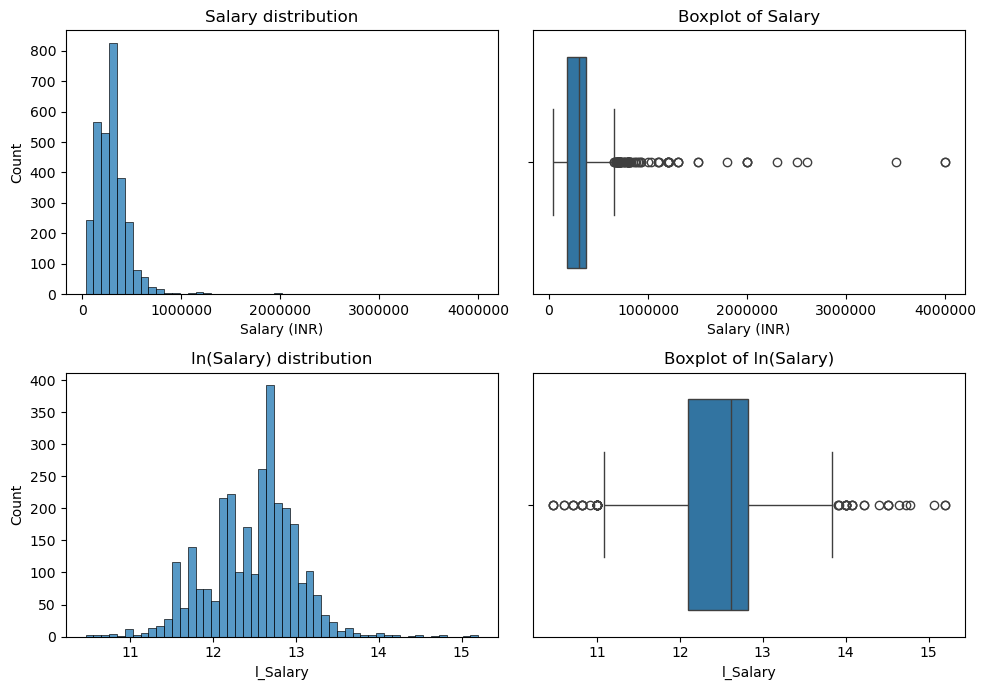

In [13]:
# compare distributions
fig, axes = plt.subplots(2, 2, figsize = (10, 7))
sns.histplot(df[response], bins = 50, ax = axes[0, 0])
axes[0, 0].set_title('Salary distribution')
axes[0, 0].ticklabel_format(axis = 'x', style = 'plain')
axes[0, 0].locator_params(axis = 'x', nbins = 6)
axes[0, 0].set_xlabel('Salary (INR)')
sns.boxplot(df[response], orient = 'h', ax = axes[0, 1])
axes[0, 1].set_title('Boxplot of Salary')
axes[0, 1].ticklabel_format(axis = 'x', style = 'plain')
axes[0, 1].locator_params(axis = 'x', nbins = 6)
axes[0, 1].set_xlabel('Salary (INR)')
sns.histplot(df['l_Salary'], bins = 50, ax = axes[1, 0])
axes[1, 0].set_title('ln(Salary) distribution')
axes[1, 0].ticklabel_format(axis = 'x', style = 'plain')
sns.boxplot(df['l_Salary'], orient = 'h', ax = axes[1, 1])
axes[1, 1].set_title('Boxplot of ln(Salary)')
plt.tight_layout()
plt.show();

In [14]:
# check skew and kurtosis
l_salary_mean = df['l_Salary'].mean()
l_salary_med = df['l_Salary'].median()
l_salary_skew = df['l_Salary'].skew()
l_salary_kurt = df['l_Salary'].kurt()
print(f'Mean ln(Salary) = {l_salary_mean:.2f}, Median ln(Salary) = {l_salary_med:.2f}')
print(f'Skew = {l_salary_skew:.2f}, Kurtosis = {l_salary_kurt:.2f}')

Mean ln(Salary) = 12.48, Median ln(Salary) = 12.61
Skew = -0.13, Kurtosis = 0.96


The original response variable Salary is heavily right skewed. 2.6% of the dataset is outliers based on the 1.5 * IQR of Salary. After applying natural log transformation, the skew greatly reduced from 6.96 to -0.13, as did the kurtosis from 94.13 to 0.96. The histogram also demonstrates a more symmetrical and uniform shape, suggesting a more normal distribution shape.

### Predictors descriptive statistics

In [15]:
# data types
df[predictors].dtypes

Gender                    object
DOB                       object
10percentage             float64
10board                   object
12graduation               int64
12percentage             float64
12board                   object
CollegeID                  int64
CollegeTier                int64
Degree                    object
Specialization            object
collegeGPA               float64
CollegeCityID              int64
CollegeCityTier            int64
CollegeState              object
GraduationYear             int64
English                    int64
Logical                    int64
Quant                      int64
Domain                   float64
ComputerProgramming        int64
ElectronicsAndSemicon      int64
ComputerScience            int64
MechanicalEngg             int64
ElectricalEngg             int64
TelecomEngg                int64
CivilEngg                  int64
conscientiousness        float64
agreeableness            float64
extraversion             float64
nueroticis

In [16]:
# summary stats for predictors
df[predictors].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
10percentage,"2,998.00",77.67,10.00,43.00,71.14,78.96,85.60,97.76
12graduation,"2,998.00","2,008.08",1.63,"1,998.00","2,007.00","2,008.00","2,009.00","2,012.00"
12percentage,"2,998.00",74.34,11.12,40.00,66.00,74.00,82.60,98.70
CollegeID,"2,998.00","5,210.21","4,776.61",2.00,526.25,"4,027.50","8,822.25","18,409.00"
CollegeTier,"2,998.00",1.92,0.26,1.00,2.00,2.00,2.00,2.00
collegeGPA,"2,998.00",71.51,8.12,6.63,66.53,71.80,76.30,99.93
CollegeCityID,"2,998.00","5,210.21","4,776.61",2.00,526.25,"4,027.50","8,822.25","18,409.00"
CollegeCityTier,"2,998.00",0.30,0.46,0.00,0.00,0.00,1.00,1.00
GraduationYear,"2,998.00","2,011.94",36.78,0.00,"2,012.00","2,013.00","2,014.00","2,017.00"
English,"2,998.00",501.07,105.30,180.00,425.00,500.00,570.00,875.00


In [17]:
# count number of colleges in sample
num_colleges = df['CollegeID'].nunique()
print(f'{num_colleges} unique colleges in sample')

1173 unique colleges in sample


In [18]:
# check numeric values < 0
neg_cols = [col for col in df.select_dtypes(exclude = 'object').columns if (df[col] == -1).sum() != 0]
neg_vals = (df[neg_cols] == -1).sum().sort_values(ascending = False)
neg_vals

CivilEngg                2972
ElectricalEngg           2876
MechanicalEngg           2811
TelecomEngg              2724
ComputerScience          2298
ElectronicsAndSemicon    2133
ComputerProgramming       650
Domain                    179
dtype: int64

While there weren't any literal nulls in the dataset, there are predictor columns with many -1 values. -1 is likely not a real academic score, so it is more likely that it is functionally a missing value.

In [19]:
# group features together
categorical_vars = ['Gender', '10board', '12board', 'CollegeTier', 'Degree', 'Specialization', 'CollegeCityTier', 'CollegeState']
date_vars = ['DOB', '12graduation', 'GraduationYear']
academic_vars = ['10percentage', '12percentage', 'collegeGPA']
score_vars = ['English', 'Logical', 'Quant', 'Domain', 'ComputerProgramming', 'ElectronicsAndSemicon',
              'ComputerScience', 'MechanicalEngg', 'ElectricalEngg', 'TelecomEngg', 'CivilEngg']
personality_vars = ['conscientiousness', 'agreeableness', 'extraversion', 'nueroticism', 'openess_to_experience']
id_vars = ['CollegeID', 'CollegeCityID']
# confirm no missing features
print(f'All predictors accounted for: {len(categorical_vars + date_vars + academic_vars + score_vars + personality_vars + id_vars) == len(predictors)}')

All predictors accounted for: True


#### Categorical features

In [20]:
# unique values in categorical features
df[categorical_vars].nunique().sort_values(ascending = False)

12board            277
10board            221
Specialization      42
CollegeState        26
Degree               4
Gender               2
CollegeTier          2
CollegeCityTier      2
dtype: int64

There is high dimensionality for the school board variables, Specialization, and CollegeState.

In [21]:
# frequency of categories
for col in categorical_vars:
  print('\n', df[col].value_counts().head(10))


 Gender
m    2282
f     716
Name: count, dtype: int64

 10board
cbse             1026
state board       881
0                 256
icse              213
ssc                96
up board           72
matriculation      29
rbse               20
wbbse              14
up                 14
Name: count, dtype: int64

 12board
cbse                               1039
state board                         948
0                                   264
icse                                101
up board                             74
isc                                  29
board of intermediate                27
board of intermediate education      21
rbse                                 16
up                                   14
Name: count, dtype: int64

 CollegeTier
2    2772
1     226
Name: count, dtype: int64

 Degree
B.Tech/B.E.      2757
MCA               200
M.Tech./M.E.       40
M.Sc. (Tech.)       1
Name: count, dtype: int64

 Specialization
electronics and communication engineering    670
comp

Gender is moderately imbalanced. CollegeTier is extremely imbalanced, with almost all observations being type 2. Degree seems to be almost entirely in Bachelors degree, with relatively few observations in the other categories (could be regrouped). Specialization is highly fragmented, but there is high concentration in the top majors.

#### Continuous features

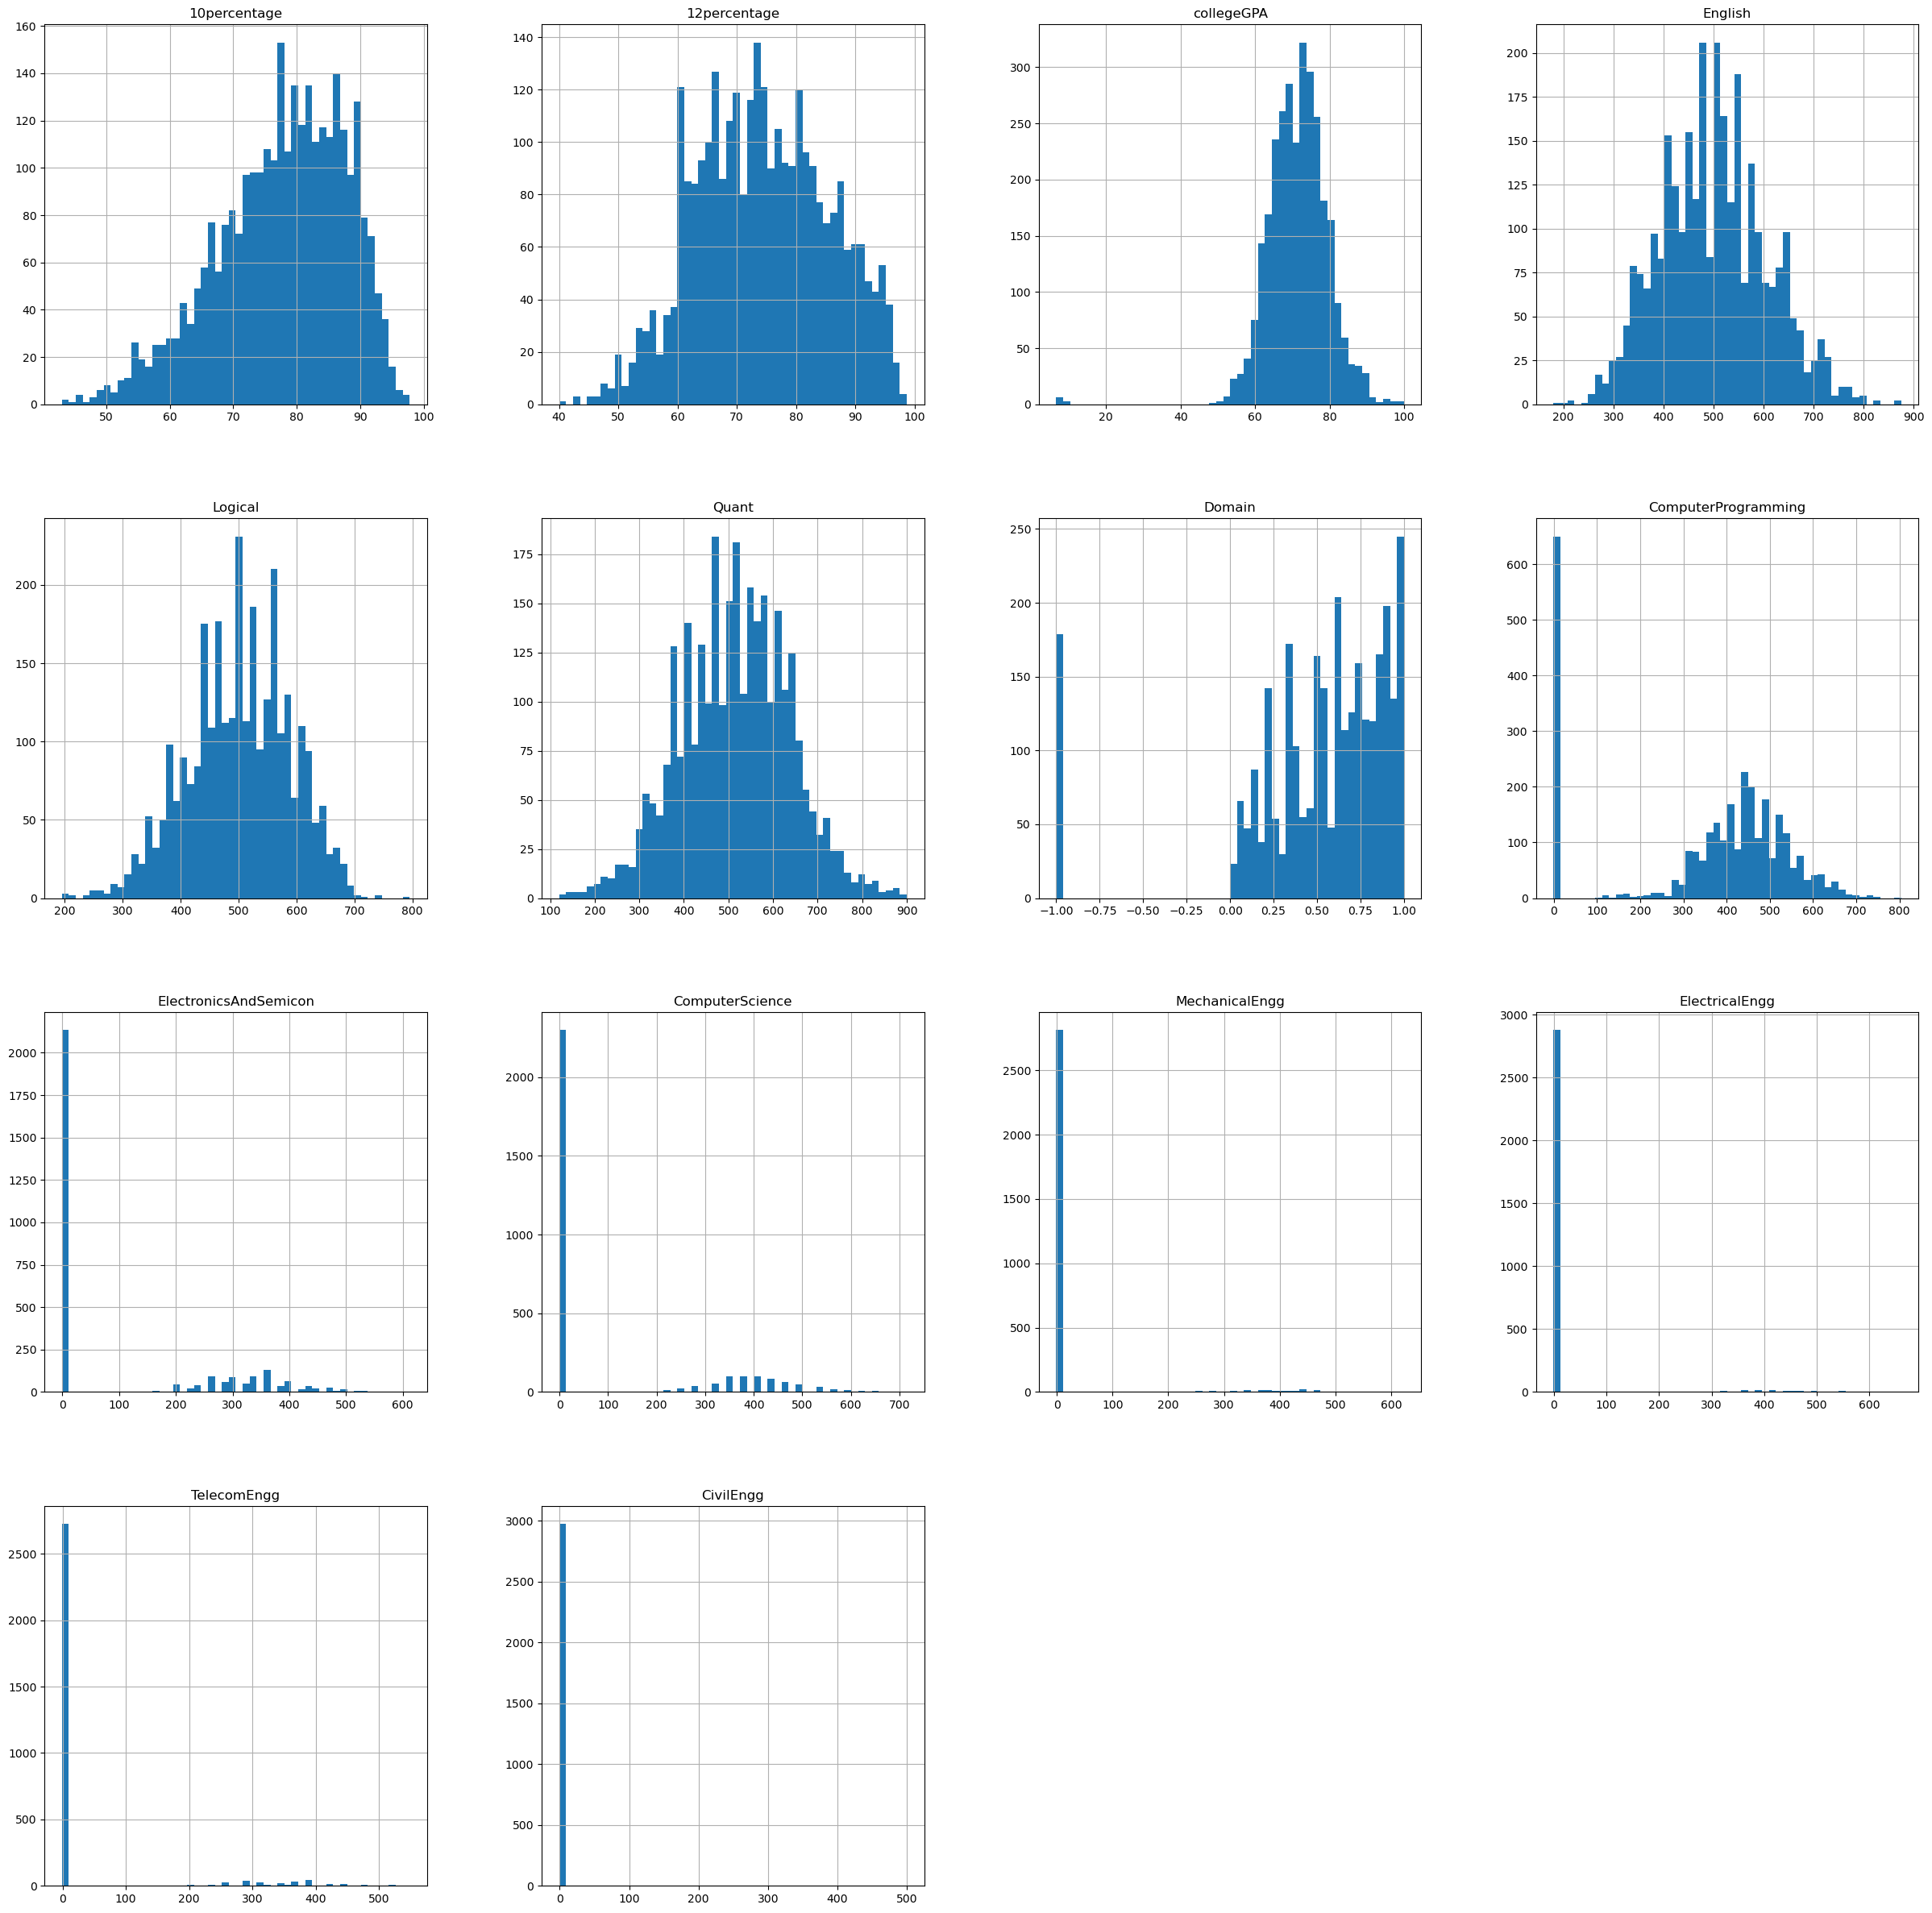

In [22]:
# distributions of continuous variables
df[academic_vars + score_vars].hist(figsize = (30, 30), bins = 50)
plt.show();

All columns with -1 values are score columns.


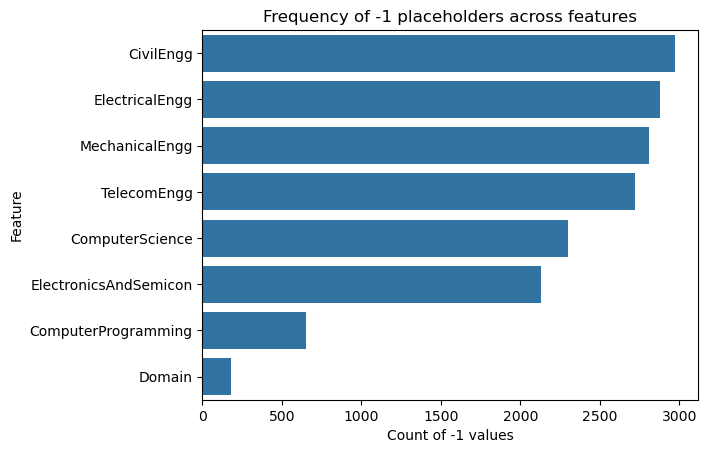

In [23]:
# plot concentration of -1 counts
diff = [col for col in neg_cols if col not in score_vars]
if len(diff) > 0:
  print(f'{len(diff)} non-score columns with -1 values.')
else:
  print('All columns with -1 values are score columns.')
sns.barplot(data = neg_vals, orient = 'h')
plt.title('Frequency of -1 placeholders across features')
plt.ylabel('Feature')
plt.xlabel('Count of -1 values')
plt.show;

Several features (all of them assessment scores) contain high concentrations of -1 placeholder values, which will not be functional for numeric analysis.

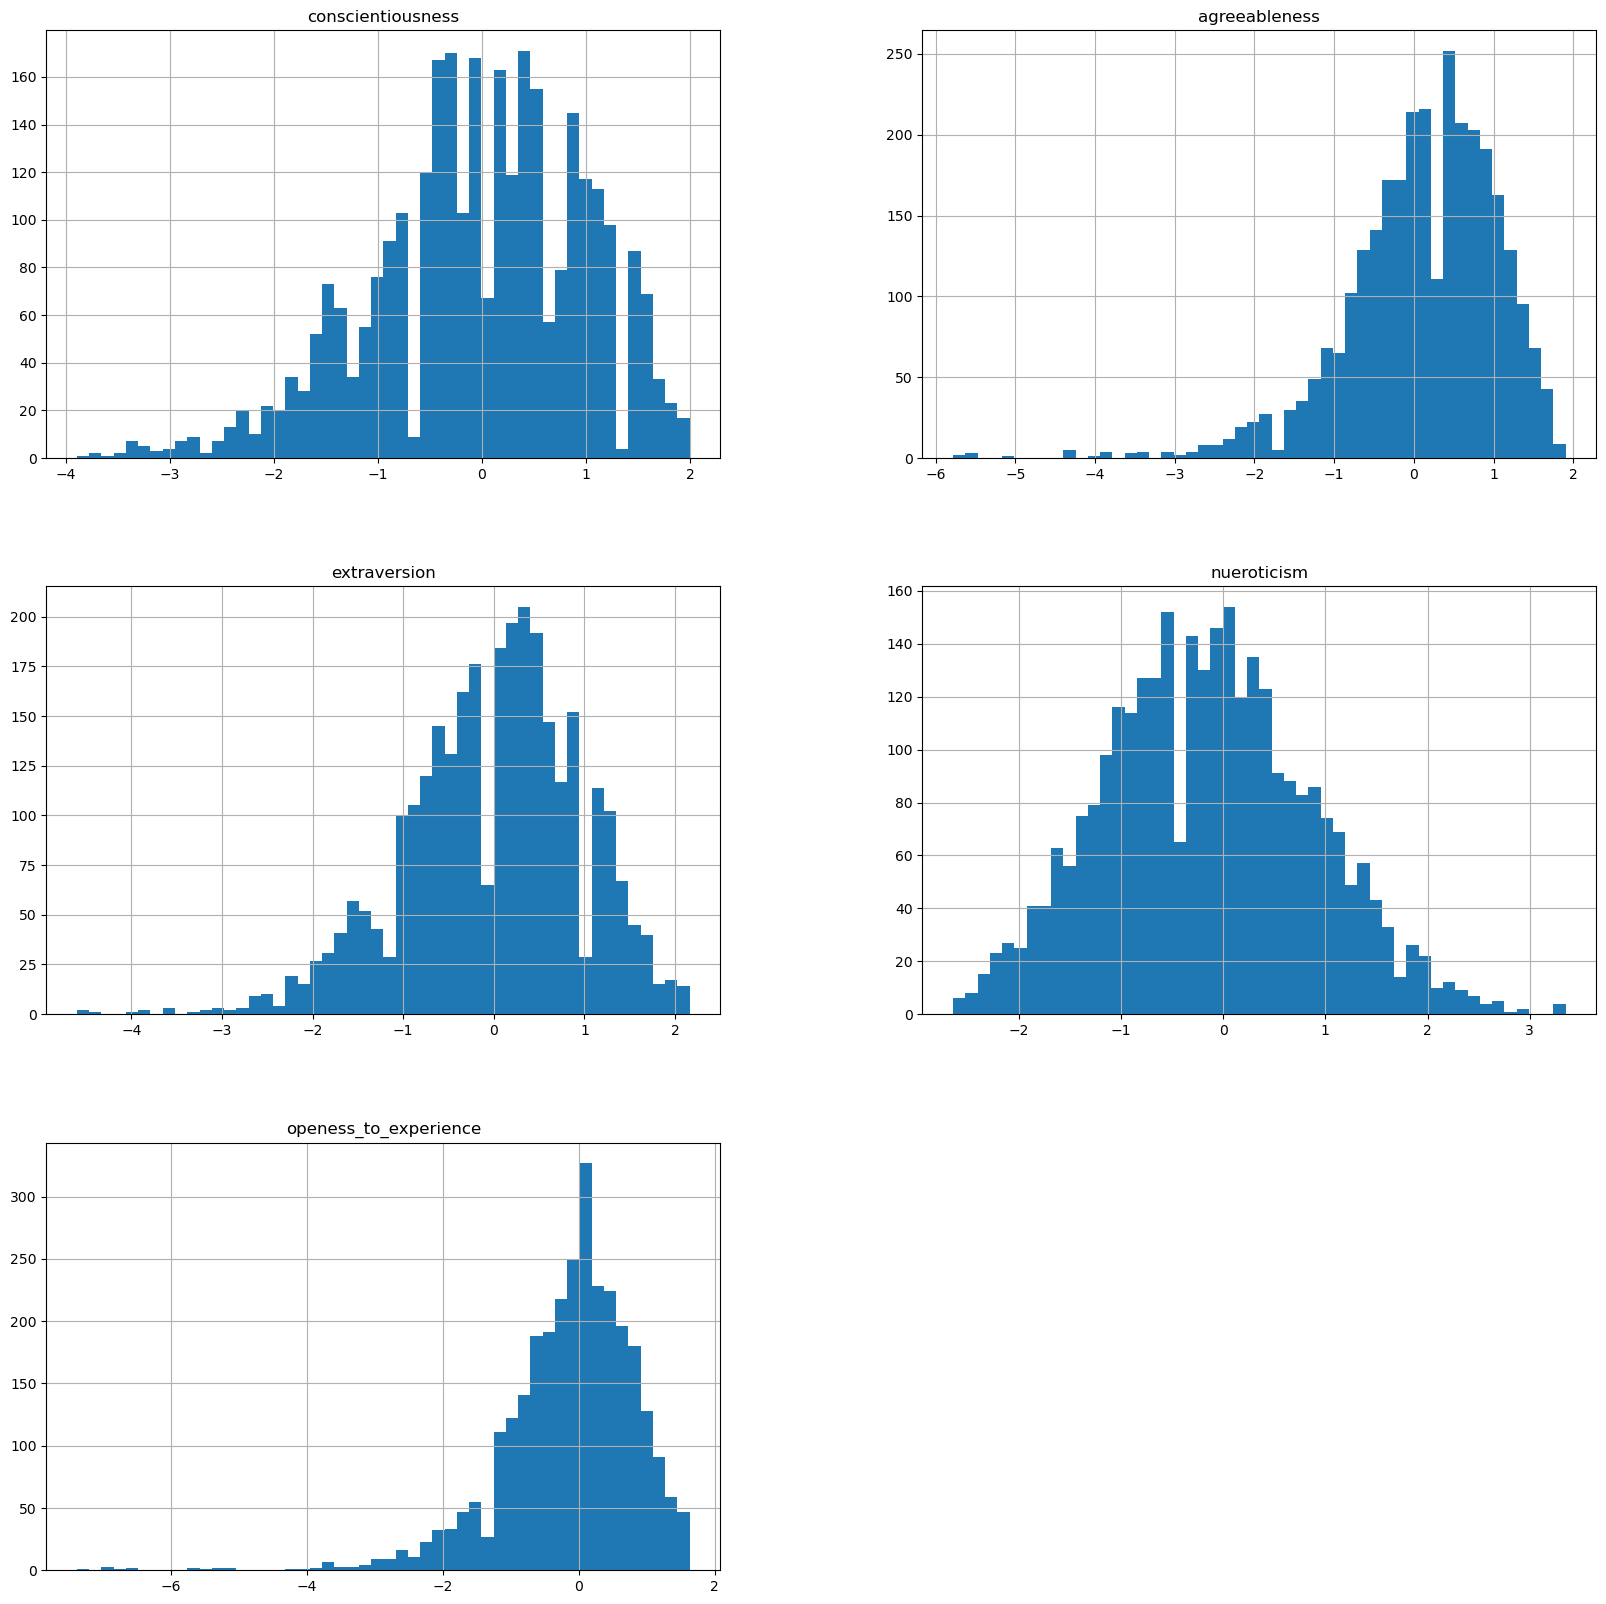

In [24]:
# distributions of personality scores
df[personality_vars].hist(figsize = (20, 20), bins = 50)
plt.show();

The personality score distributions all appear to be centered around 0.

### Correlations and collinearity

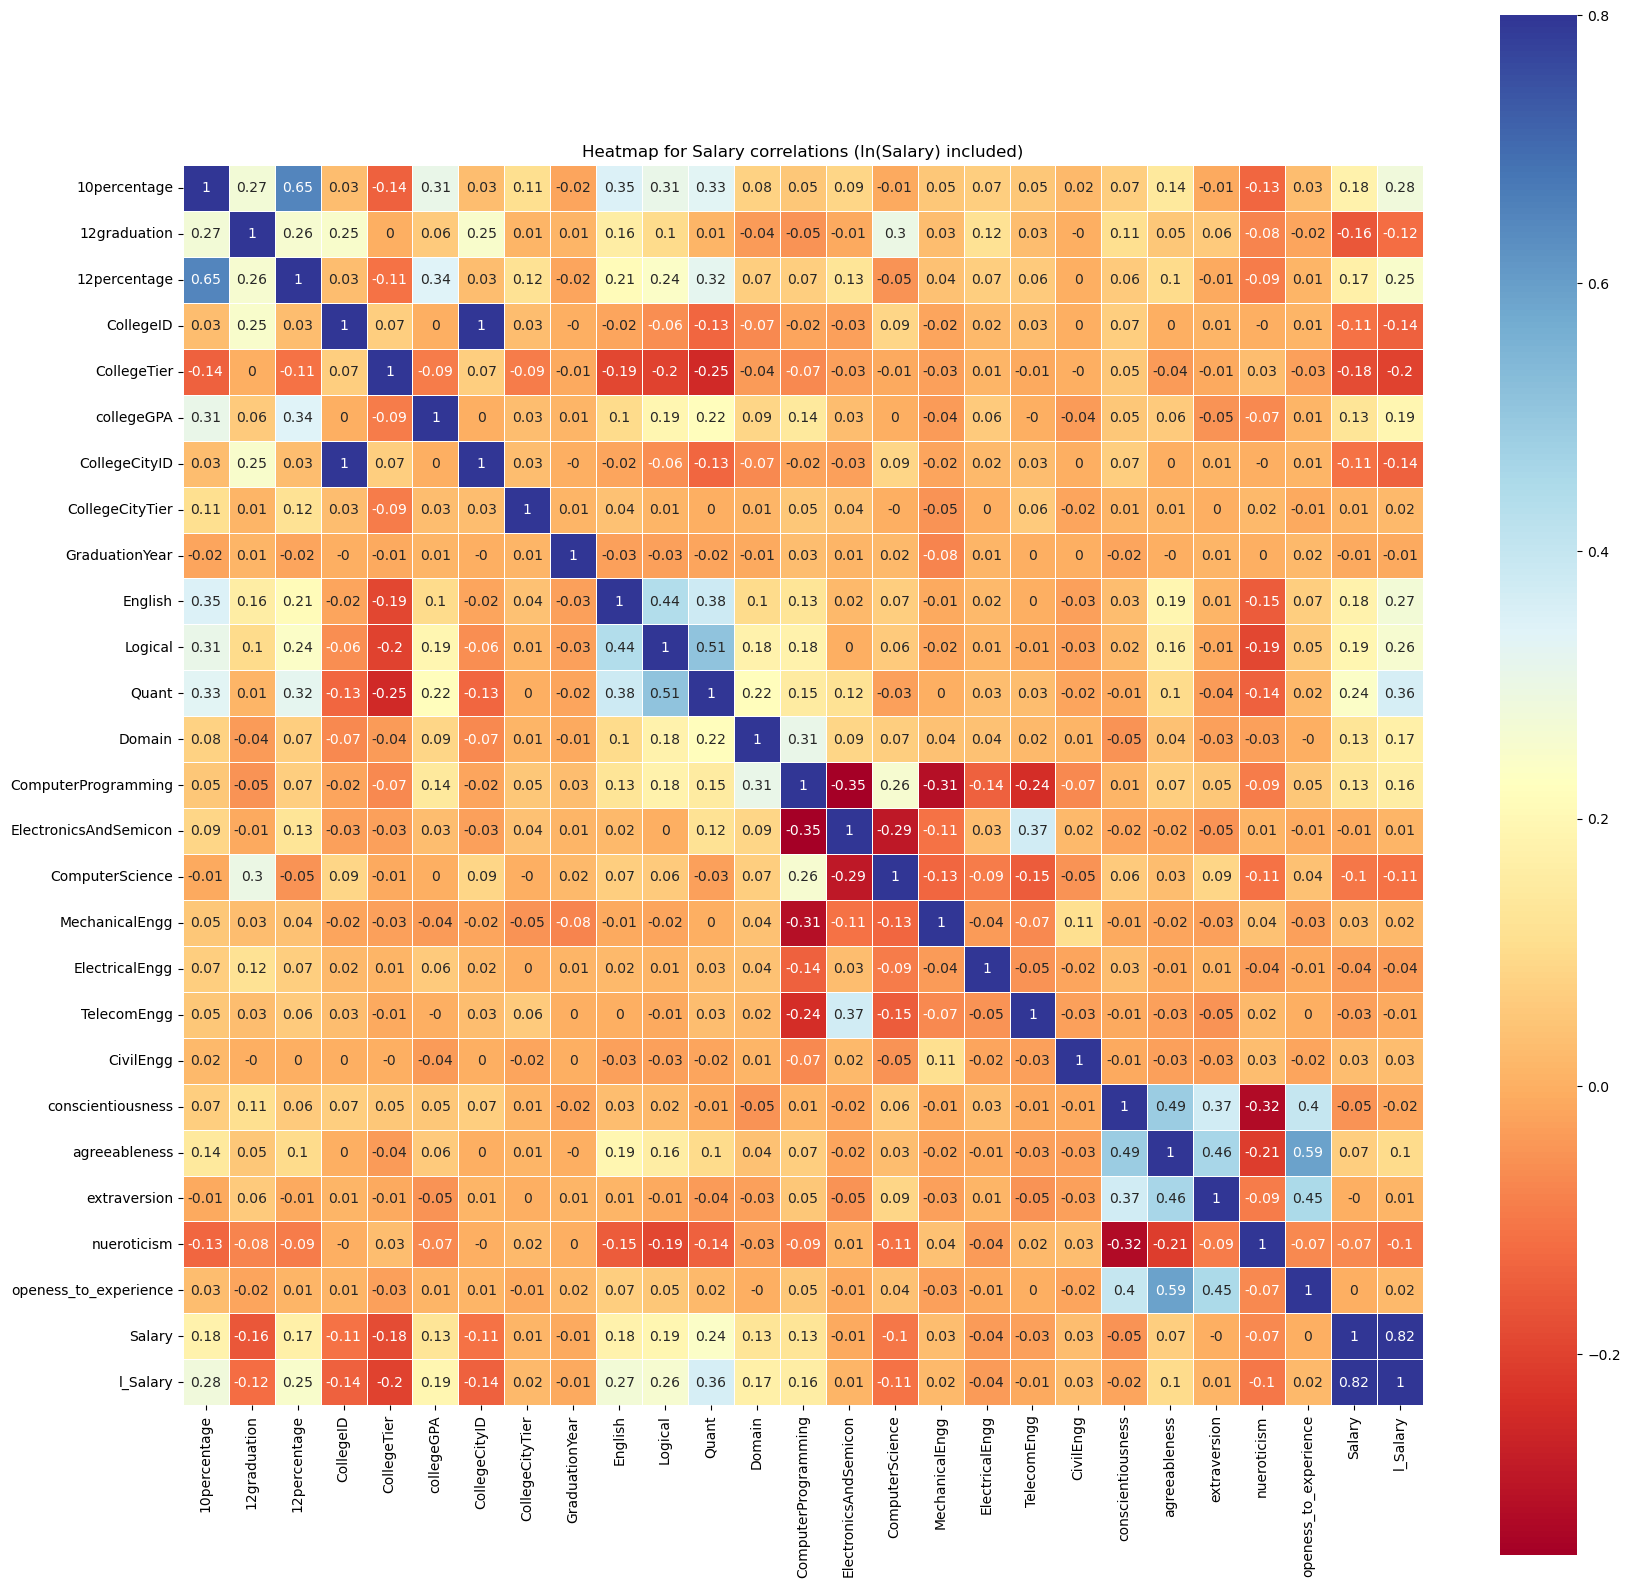

In [25]:
# top correlations with salary
df_corr = df.select_dtypes(include = 'number')
corrmat = df_corr.corr().round(2)
f, ax = plt.subplots(figsize = (20, 20))
ax = sns.heatmap(corrmat, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
ax.tick_params(axis='y', rotation = 0)
plt.title('Heatmap for Salary correlations (ln(Salary) included)')
plt.show();

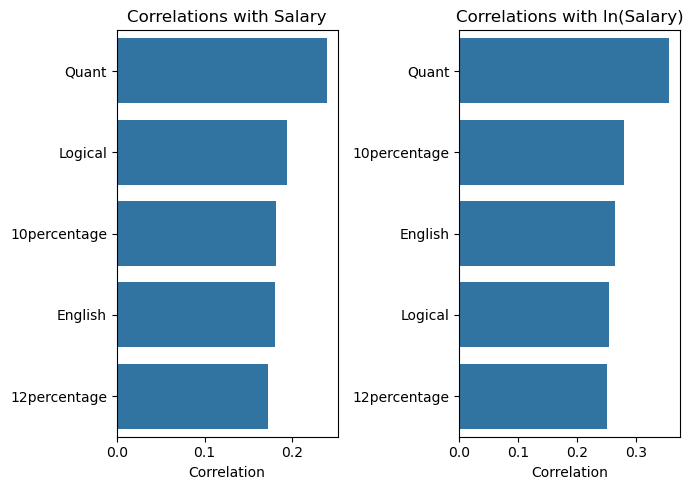

In [26]:
# view highest correlated predictors with Salary and l_Salary
top_corr = df_corr.corr()[response].drop(['Salary', 'l_Salary']).sort_values(ascending = False).head()
l_top_corr = df_corr.corr()['l_Salary'].drop(['Salary', 'l_Salary']).sort_values(ascending = False).head()
fig, axes = plt.subplots(1, 2, figsize = (7, 5))
sns.barplot(x = top_corr.values, y = top_corr.index, ax = axes[0])
axes[0].set_title('Correlations with Salary')
axes[0].set_ylabel(None)
axes[0].set_xlabel('Correlation')
sns.barplot(x = l_top_corr.values, y = l_top_corr.index, ax = axes[1])
axes[1].set_title('Correlations with ln(Salary)')
axes[1].set_ylabel(None)
axes[1].set_xlabel('Correlation')
plt.tight_layout()
plt.show();

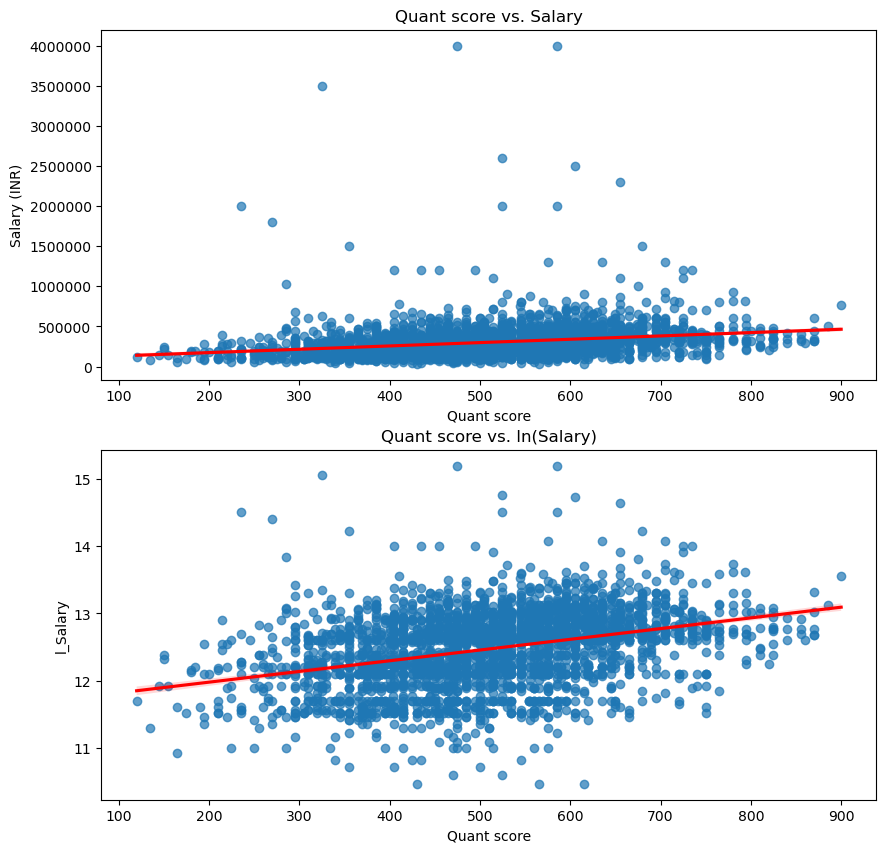

In [27]:
# quant vs salary scatterplot
fig, axes = plt.subplots(2, 1, figsize = (10, 10))
sns.regplot(data = df, 
            x = 'Quant', 
            y = response, 
            line_kws = {'color':'red'}, 
            scatter_kws = {'alpha': 0.7},
            ax = axes[0])
axes[0].set_title('Quant score vs. Salary')
axes[0].ticklabel_format(axis = 'y', style = 'plain')
axes[0].set_ylabel('Salary (INR)')
axes[0].set_xlabel('Quant score')
sns.regplot(data = df, 
            x = 'Quant', 
            y = 'l_Salary',
            line_kws = {'color':'red'}, 
            scatter_kws = {'alpha': 0.7}, 
            ax = axes[1])
axes[1].set_title('Quant score vs. ln(Salary)')
axes[1].set_xlabel('Quant score')
plt.show();

There are no individual features with strong correlations with Salary. Quant has a moderate positive correlation with log-transformed Salary. There are some moderate to strong correlations among predictors, particularly the assessment scores.

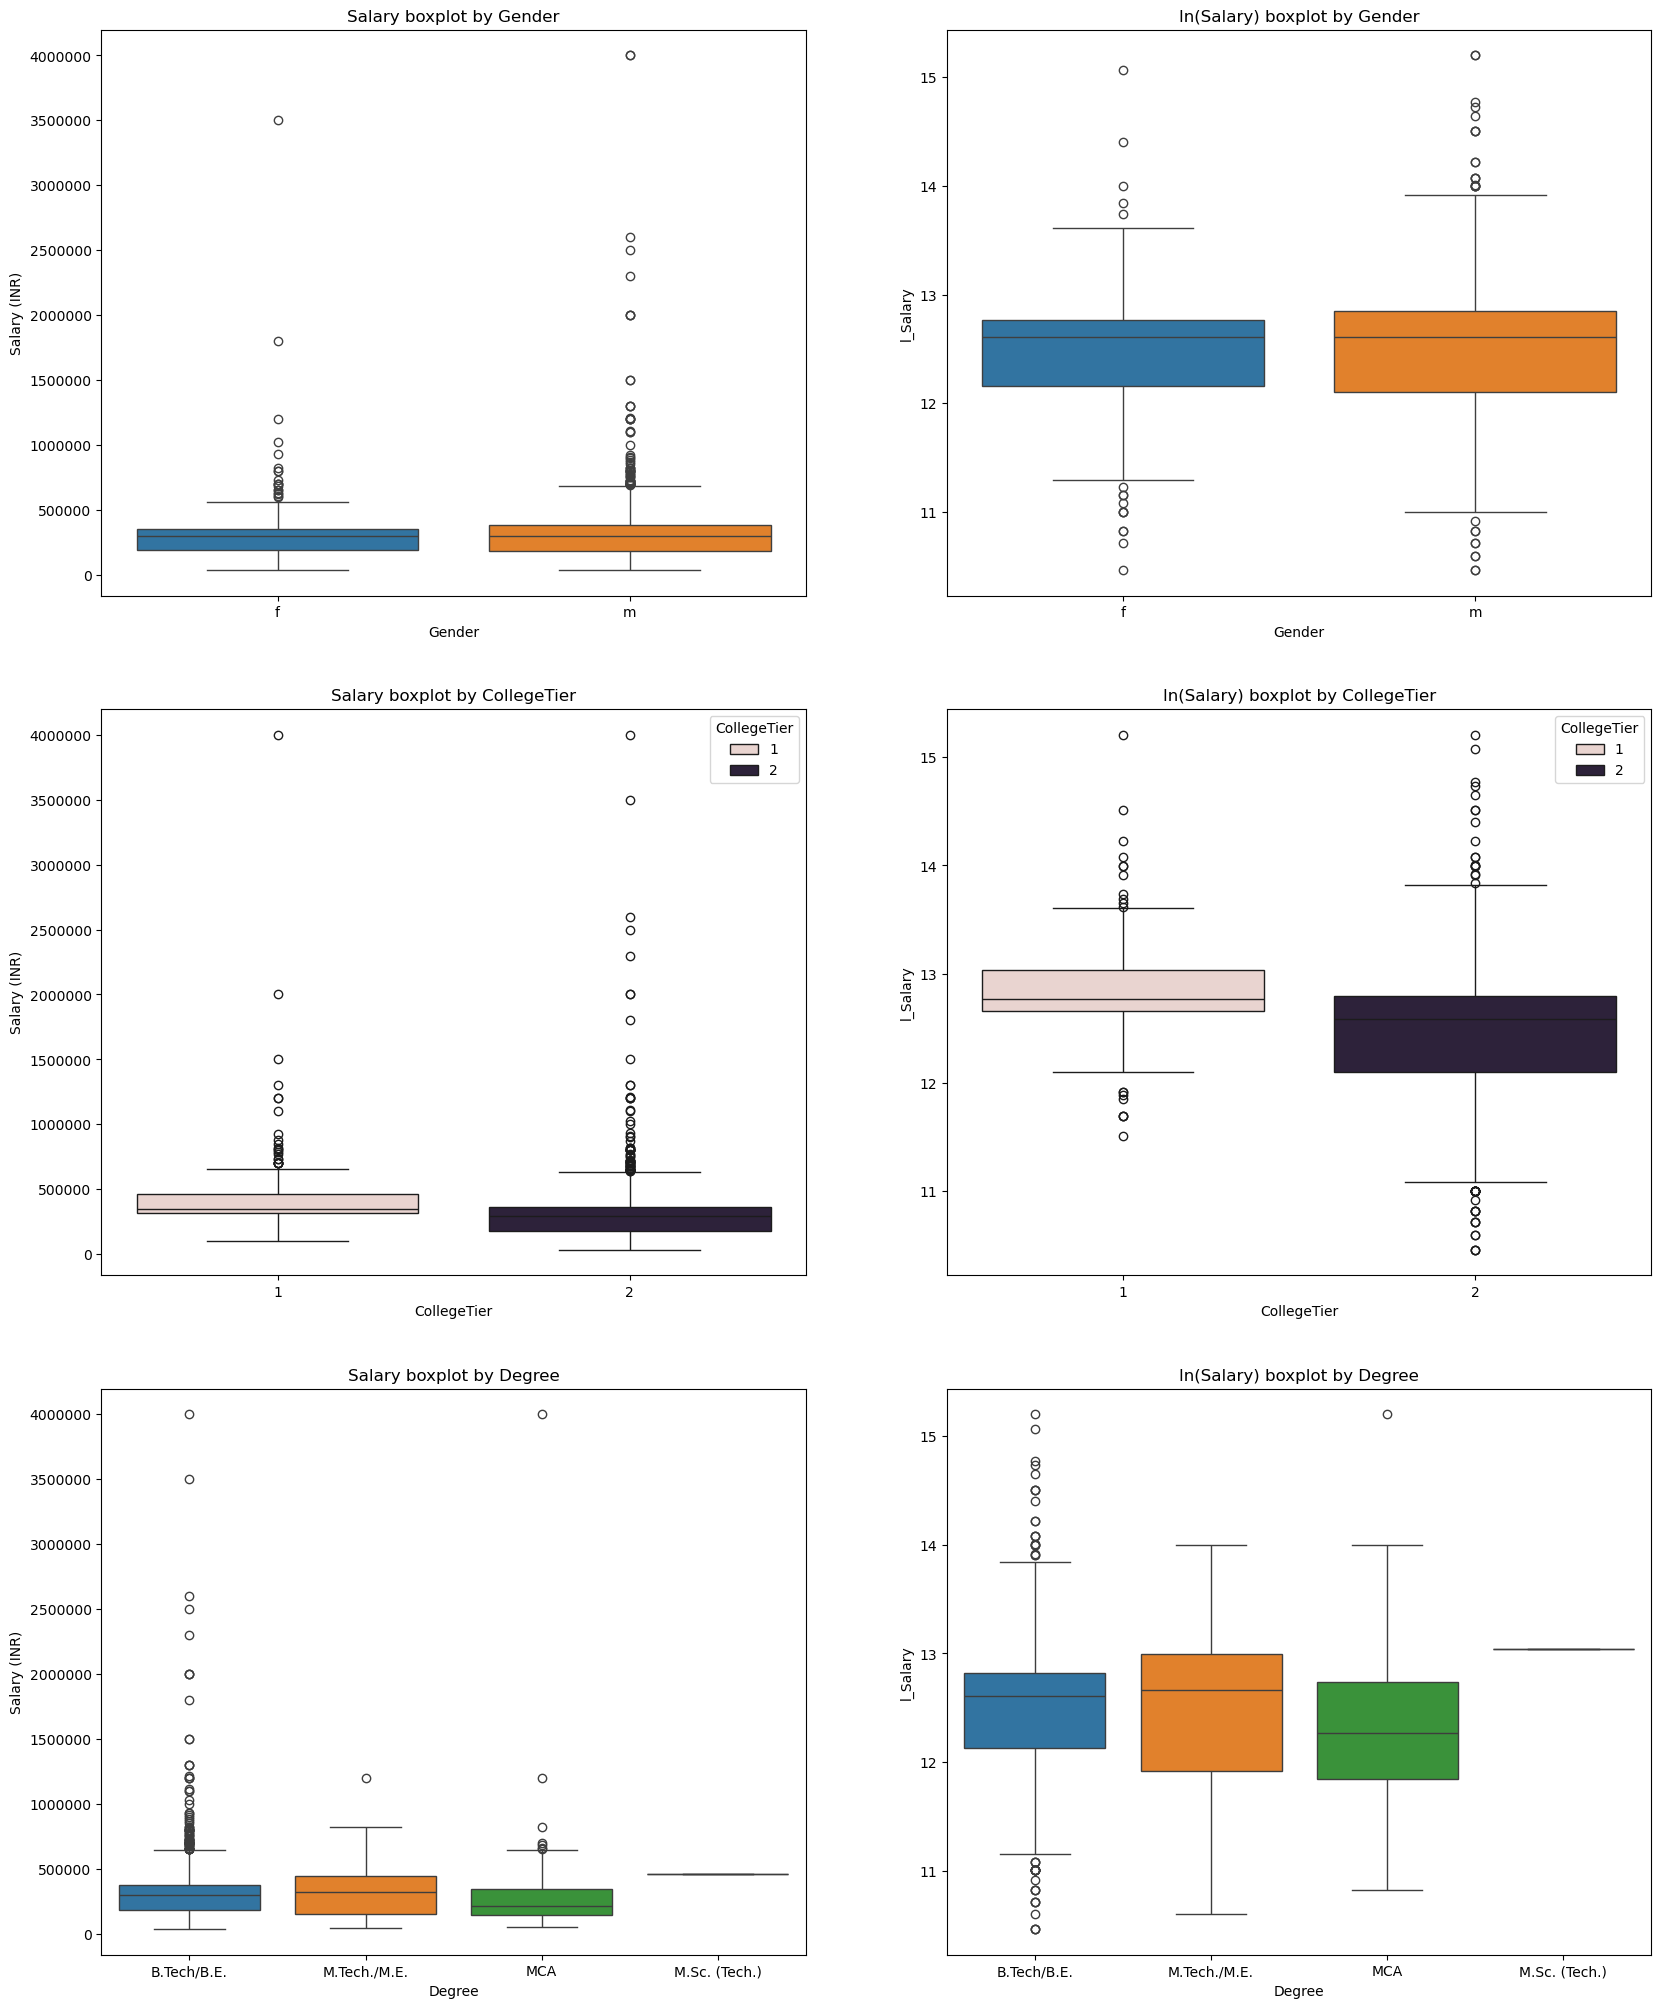

In [28]:
# boxplots of salary with low dimensional categories
fig, axes = plt.subplots(3, 2, figsize = (20, 25))
sns.boxplot(data = df, x = 'Gender', y = response, hue = 'Gender', ax = axes[0, 0])
axes[0, 0].set_title('Salary boxplot by Gender')
axes[0, 0].ticklabel_format(axis = 'y', style = 'plain')
axes[0, 0].set_ylabel('Salary (INR)')
sns.boxplot(data = df, x = 'Gender', y = 'l_Salary', hue = 'Gender', ax = axes[0, 1])
axes[0, 1].set_title('ln(Salary) boxplot by Gender')
sns.boxplot(data = df, x = 'CollegeTier', y = response, hue = 'CollegeTier', ax = axes[1, 0])
axes[1, 0].set_title('Salary boxplot by CollegeTier')
axes[1, 0].ticklabel_format(axis = 'y', style = 'plain')
axes[1, 0].set_ylabel('Salary (INR)')
sns.boxplot(data = df, x = 'CollegeTier', y = 'l_Salary', hue = 'CollegeTier', ax = axes[1, 1])
axes[1, 1].set_title('ln(Salary) boxplot by CollegeTier')
sns.boxplot(data = df, x = 'Degree', y = response, hue = 'Degree', ax = axes[2, 0])
axes[2, 0].set_title('Salary boxplot by Degree')
axes[2, 0].ticklabel_format(axis = 'y', style = 'plain')
axes[2, 0].set_ylabel('Salary (INR)')
sns.boxplot(data = df, x = 'Degree', y = 'l_Salary', hue = 'Degree', ax = axes[2, 1])
axes[2, 1].set_title('ln(Salary) boxplot by Degree')
plt.show();

The Salary (original and log-transformed) shows similar medians across categories, except for CollegeTier. There is a visible distinction in the boxplots between CollegeTiers 1 and 2. This could be an influential predictor, but the CollegeTier feature is also heavily imbalanced.

## Data Preparation & Feature Engineering

### Drop features

In [29]:
# drop IDs and boards
df_clean = df.copy()
df_clean = df_clean.drop(columns = id_vars)
df_clean = df_clean.drop(columns = ['10board', '12board'])
df_clean.shape

(2998, 30)

The CollegeID, CollegeCityID, 10board, and 12board features added a lot of levels to the dataset and likely have low practical signal.

### Continuous feature preparation

In [30]:
# replace -1 values with Nan
df_clean[neg_cols] = df_clean[neg_cols].replace(-1, np.nan)

As discussed earlier, the -1 values are not functional. First step in dealing with these reclassifying them as missing values. These can then be imputed in preprocessing.

In [31]:
# handle date variables
df_clean['DOB'] = pd.to_datetime(df_clean['DOB'])
df_clean['GradAge'] = df_clean['GraduationYear'] - df_clean['DOB'].dt.year
df_clean = df_clean.drop('DOB', axis = 1)
date_vars.remove('DOB')
date_vars.append('GradAge')

Substituted the DOB feature with an age at graduation feature.

### Categorical feature preparation

In [32]:
# regroup degree
df_clean['Degree'] = df_clean['Degree'].replace({'M.Tech./M.E.':'Other', 'M.Sc. (Tech.)':'Other'})
# regroup specializations
spec_count = df_clean['Specialization'].value_counts()
top_specs = spec_count[spec_count >= 100].index
df_clean['Specialization'] = df_clean['Specialization'].apply(lambda x: x if x in top_specs else 'Other')

The Masters degree classes in Degree were regrouped as Other because the observations were almost entirely in the Bachelors degree class. Specialization originally had 42 classes, so, the classes with fewer than 100 observations were regrouped as Other to reduce dimensionality.

### Additional Feature Engineering

In [33]:
# create academic consistency feature
df_clean['AcademicConsistency'] = (
    df_clean['10percentage'] + df_clean['12percentage'] + df_clean['collegeGPA']
    ) / 3

In [34]:
# create academic growth feature
df_clean['AcademicGrowth'] = df_clean['collegeGPA'] - df_clean['12percentage']

In addition to the log-transformed response variable and GradAge feature, I have added a feature which averages the grade in class 10, class 12, and college GPA (which also appears to be a percentage) to capture academic consistency. I have also added a feature which takes the difference between college GPA and grade in class 12 to find any improvement in academic performance.

### Preprocessing pipeline

In [35]:
# assign X and y (log transformed)
X = df_clean.drop(columns = ['Salary', 'l_Salary'])
y = df_clean['l_Salary']

In [36]:
# split numeric vs categorical
numeric_features = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include = ['object']).columns.tolist()

In [37]:
# median impute and robust scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', RobustScaler())])
# one hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))])

In [38]:
# build pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)])

<p>The log-transformed Salary variable is a preferable response variable because it demonstrates a more symmetric and normal shape than the original Salary variable and will be less sensitive to outlier observations. l_Salary will be the primary resposne variable going forward, and modeling predictions will be transformed back to the original INR scale.</p>
<p>To continue preprocessing, the numeric features are imputed with the median (addresses the unusable -1 values) and scaled to reduce sensitivity to outliers. The categorical features are mode-imputed and one-hot encoded to create dummy variables.

## Modeling

### Design & model selection

In [39]:
# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f'Training set size: {len(X_train)}. Test set size: {len(X_test)}')

Training set size: 2398. Test set size: 600


The models will be fit on the training set with 2398 observations and predictions will be made on the hold-out set with 600 observations.

In [40]:
# function for evaluation metrics
def eval_model(y_test, y_pred):
  return {
      'MAE': mean_absolute_error(y_test, y_pred),
      'MSE': mean_squared_error(y_test, y_pred),
      'R2': r2_score(y_test, y_pred)
      }

Defined the function eval_model to provide goodness of fit metrics for each model. Models will be evaluated on mean absolute error, mean squared error, and R^2.

### Linear regression

In [41]:
# build linear regression model
linear_model = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])

In [42]:
# fit linear model on training
linear_model.fit(X_train, y_train)
# make test predictions
lm_pred = linear_model.predict(X_test)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['10percentage',
                                                   '12graduation',
                                                   '12percentage',
                                                   'CollegeTier', 'collegeGPA',
                                                   'CollegeCityTier',
                                                   'GraduationYear', 'English',
                                                   'Logical', 'Quant', 'Domain',
                                                   'ComputerProgramming',
                                                   'ElectronicsAndSemicon'...
                                                   'conscientiousness',
                                                   'agreeableness',
                                                   'extraversion',
                                                   'nueroticism',
                                                   'openess_to_experience',
                                                   'GradAge',
                                                   'AcademicConsistency',
                                                   'AcademicGrowth']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Degree',
                                                   'Specialization',
                                                   'CollegeState'])])),
                ('model', LinearRegression())])

### Ridge regression

In [43]:
# build ridge model
ridge_model = Pipeline([('preprocessor', preprocessor), ('model', Ridge(alpha = 1.0))])

In [44]:
# fit ridge model on training
ridge_model.fit(X_train, y_train)
# make test predictions
ridge_pred = ridge_model.predict(X_test)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['10percentage',
                                                   '12graduation',
                                                   '12percentage',
                                                   'CollegeTier', 'collegeGPA',
                                                   'CollegeCityTier',
                                                   'GraduationYear', 'English',
                                                   'Logical', 'Quant', 'Domain',
                                                   'ComputerProgramming',
                                                   'ElectronicsAndSemicon'...
                                                   'TelecomEngg', 'CivilEngg',
                                                   'conscientiousness',
                                                   'agreeableness',
                                                   'extraversion',
                                                   'nueroticism',
                                                   'openess_to_experience',
                                                   'GradAge',
                                                   'AcademicConsistency',
                                                   'AcademicGrowth']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Degree',
                                                   'Specialization',
                                                   'CollegeState'])])),
                ('model', Ridge())])

### Random forest

In [45]:
# build random forest model
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RF(random_state = 42))])

In [46]:
# hyperparameter tuning
rf_params = {'model__n_estimators': [100, 200, 300],
             'model__max_depth': [5, 10, None]}
rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions = rf_params,
    n_iter = 20,
    cv = 5,
    scoring = 'r2',
    random_state = 42,
    n_jobs = -1)

rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
# print best parameters
print('Best params: ', rf_search.best_params_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['10percentage',
                                                                                '12graduation',
                                                                                '12percentage',
                                                                                'CollegeTier',
                                                                                'collegeGPA',
                                                                                'CollegeCityTier',
                                                                                'GraduationYear',
                                                                                'English',
                                                                                'Logical',
                                                                                'Quant',
                                                                                'Domain',
                                                                                'ComputerPr...
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Degree',
                                                                                'Specialization',
                                                                                'CollegeState'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, None],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

Best params:  {'model__n_estimators': 300, 'model__max_depth': None}


In [47]:
# make test predictions
rf_pred = rf_best.predict(X_test)

### Gradient boosting

In [48]:
# build gb model
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GBR(random_state = 42))])

In [49]:
# hyperparameter tuning
gb_params = {'model__n_estimators': [100, 200, 300],
             'model__learning_rate': [0.01, 0.05, 0.1],
             'model__max_depth': [2, 3, 4]}
gb_search = RandomizedSearchCV(
    gb_model,
    param_distributions = gb_params,
    n_iter = 20,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1,
    random_state = 42
)

gb_search.fit(X_train, y_train)
gb_best = gb_search.best_estimator_
# print best parameters
print('Best params: ', gb_search.best_params_)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['10percentage',
                                                                                '12graduation',
                                                                                '12percentage',
                                                                                'CollegeTier',
                                                                                'collegeGPA',
                                                                                'CollegeCityTier',
                                                                                'GraduationYear',
                                                                                'English',
                                                                                'Logical',
                                                                                'Quant',
                                                                                'Domain',
                                                                                'ComputerPr...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Degree',
                                                                                'Specialization',
                                                                                'CollegeState'])])),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [2, 3, 4],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

Best params:  {'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.05}


In [50]:
# make test predictions
gb_pred = gb_best.predict(X_test)

Performed some hyperparameter tuning on the Random Forest and Gradient Boosting models using RandomizedSearchCV. The best models from the tuning were the ones fit and used to make predictions.

### Model performance

In [51]:
# goodness of fit metrics
log_results = pd.DataFrame({
    'Linear': eval_model(y_test, lm_pred),
    'Ridge': eval_model(y_test, ridge_pred),
    'RF': eval_model(y_test, rf_pred),
    'GBR': eval_model(y_test, gb_pred)
})
log_results.round(3)

,Linear,Ridge,RF,GBR
MAE,0.35,0.35,0.35,0.34
MSE,0.21,0.21,0.21,0.20
R2,0.24,0.24,0.24,0.27


Gradient Boosting is the best performing model at predicting the log-transformed salary. The Ridge model seems to add no gains to the linear model.The low R^2 scores across all models indicate that salary may be inherently difficult to predict given the available feature set. A larger data sample, more features such as internship experience, or different ML techniques may explain more variation in salary and yield better predictions.

In [52]:
# convert to original scale
y_test_exp = np.exp(y_test)
lm_pred_exp = np.exp(lm_pred)
ridge_pred_exp = np.exp(ridge_pred)
rf_pred_exp = np.exp(rf_pred)
gb_pred_exp = np.exp(gb_pred)
# goodness of fit metrics
results = pd.DataFrame({
    'Linear': eval_model(y_test_exp, lm_pred_exp),
    'Ridge': eval_model(y_test_exp, ridge_pred_exp),
    'RF': eval_model(y_test_exp, rf_pred_exp),
    'GBR': eval_model(y_test_exp, gb_pred_exp)
})
results

,Linear,Ridge,RF,GBR
MAE,"98,801.72","98,815.26","99,558.82","96,982.51"
MSE,"24,357,062,769.51","24,380,558,320.48","24,497,181,839.40","23,579,166,723.13"
R2,0.18,0.17,0.17,0.20


After converting back to the original salary units, Gradient Boosting still performs better. The mean absolute error of the Gradient Boosting model is 96,982.51 rupees.

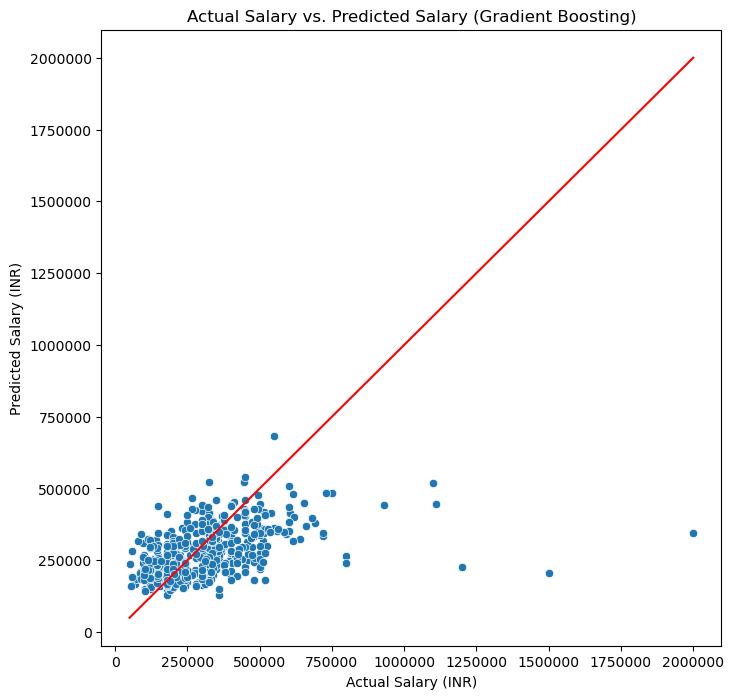

In [53]:
# prediction vs actual plot
plt.figure(figsize = (8, 8))
sns.scatterplot(x = y_test_exp, y = gb_pred_exp)
plt.plot([y_test_exp.min(), y_test_exp.max()], [y_test_exp.min(), y_test_exp.max()], color = 'red')
plt.ticklabel_format(axis = 'both', style = 'plain')
plt.xlabel('Actual Salary (INR)')
plt.ylabel('Predicted Salary (INR)')
plt.title('Actual Salary vs. Predicted Salary (Gradient Boosting)')
plt.show();

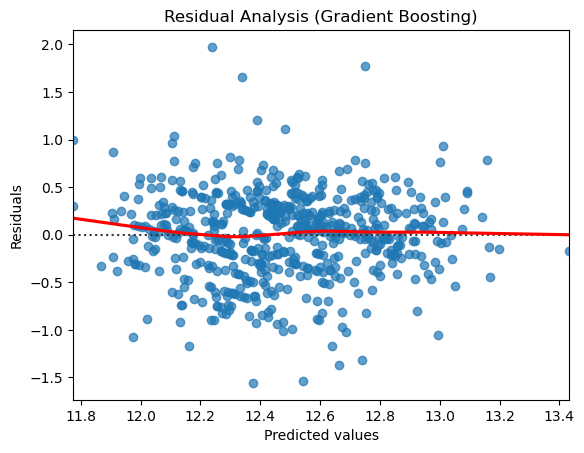

In [54]:
# residual plot
sns.residplot(x = gb_pred,
              y = y_test,
              lowess = True,
              line_kws = {'color':'red'},
              scatter_kws = {'alpha': 0.7})
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual Analysis (Gradient Boosting)')
plt.show();

In [55]:
# feature importance
feature_importance = (gb_best.named_steps['model'].feature_importances_)
feature_names = (gb_best.named_steps['preprocessor'].get_feature_names_out())
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending = False)
importance_df['Feature'] = importance_df['Feature'].str.replace('num__','')
importance_df.head(10)

,Feature,Importance
9,Quant,0.25
6,GraduationYear,0.12
24,AcademicConsistency,0.11
7,English,0.09
11,ComputerProgramming,0.06
3,CollegeTier,0.03
10,Domain,0.03
0,10percentage,0.03
4,collegeGPA,0.03
18,conscientiousness,0.03


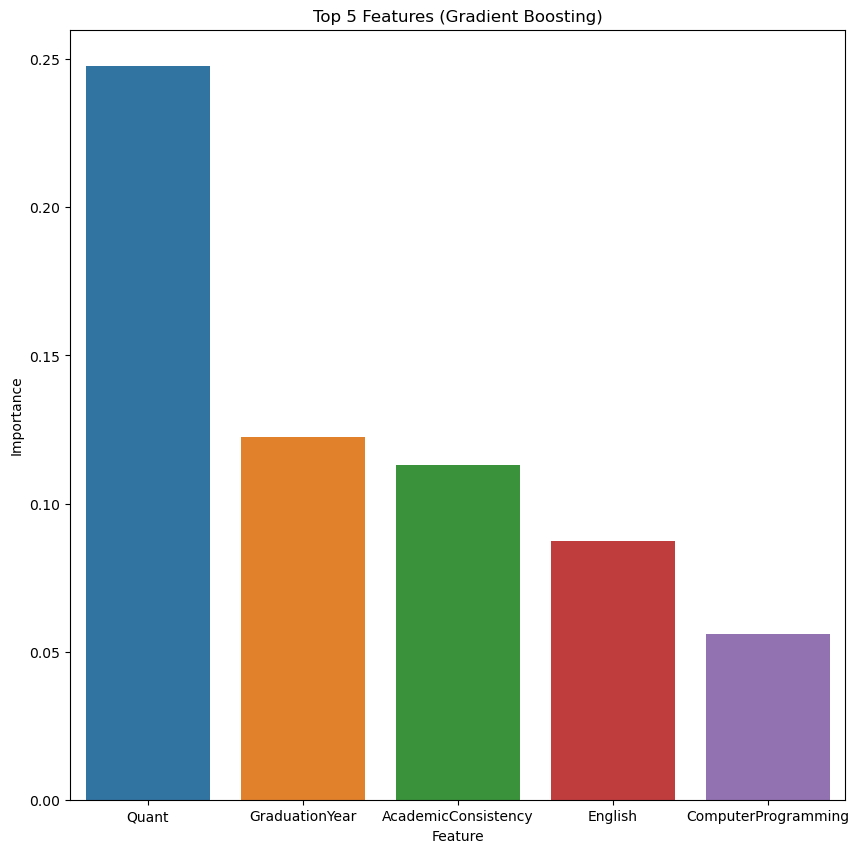

In [56]:
# feature importance bar chart
plt.figure(figsize = (10, 10))
sns.barplot(data = importance_df.head(), x = 'Feature', y = 'Importance', hue = 'Feature')
plt.title('Top 5 Features (Gradient Boosting)')
plt.show();

### Findings & Conclusions
<p>Partially predicting salary is possible, but these models only explain a portion of the variation. Improving predictive power and accuracy would likely involve using a larger sample, obtaining more predictor features in the data like internship experience, and testing other learning techniques like neural networks.</p>
<p>The most important features from the Gradient Boosting model were Quant, AcademicConsistency, English, and ComputerProgramming. EDA supports that variation in median salary does show up in Quant scores, so it could be interpreted that investing in quantitative training could improve overall salary outcomes. AcademicConsistency was one of the engineered features measuring the average grades from 10th grade through college. Its importance could mean that a lower college GPA compared to high school grades could be an early indicator that the student needs support. English scores are also an important feature, indicating that employers value this skill and it could be emphasized at the university level.